<a href="https://colab.research.google.com/github/Teapot-t/kurs-Uczenie-Maszynowe/blob/main/zadanie_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import Ridge, Lasso

# Tworzymy ground truth model i dane testowe
Zakładamy 50 zmiennych predykcyjnych, z których tylko pierwsze 5 ma wpływ na wynik (ze współczynnikiem 1), reszta to jedynie szum losowy. Tzn nasz "idealny" model ma postać
$f(X)=\sum_0^4 X_i$
Tworzymy dane do modelu testowego wraz z ich idealnymi odpowiedziami modelu, pozbawionymi szumu losowego (irreducible error). Dane do zbioru testowego (i treningowych) będą miały rozkład normalny. Posłużą do oszacowania wariancji i biasu.

In [66]:
beta = np.zeros(50)
beta[0:5] = 1
#funkcja do generowania danych, testowych i treningowych dla naszego modelu
def generate_set(s = 1000):
    X = np.random.normal(0, 1, size=(s, 50))  #generujemy obserwacje
    noise = np.random.normal(0, 1, size=s)  #generujemy szum
    Y = X @ beta + noise                          #obliczamy 'idealny' model
    Y_true = X @ beta                             #obliczamy ground truth (potrzebny potem do biasu)
    return X, Y, Y_true

In [67]:
#generujemy dane do testowania - będą stałe na potrzebę badania każdego wytrenowanego modelu
X_test, Y_test, Y_test_true = generate_set()

# Przechodzimy do trenowania modeli
dla każdego rodzaju modelu (ridge i lasso) dla każdego parametru lambda, tworzymy 100 modeli (poprzez ponowne wylosowanie nowych danych treningowych), zapisujemy wyniki w celu zbadania metryk.

In [68]:
lambdas = np.logspace(-5, 5, 100)
results = []
for l in lambdas:

    ridge_predictions = []
    lasso_predictions = []
    #trenujemy 200 różnych modeli przez wygenerowanie nowych syntetycznych zbiorów danych
    for i in range(200):
        X_train, Y_train, Y_train_true = generate_set(s=30)

        ridge = Ridge(alpha=l, max_iter=10000)
        ridge.fit(X_train, Y_train)
        ridge_predictions.append(ridge.predict(X_test))

        lasso = Lasso(alpha=l, max_iter=10000)
        lasso.fit(X_train, Y_train)
        lasso_predictions.append(lasso.predict(X_test))

    ridge_preds = np.array(ridge_predictions)
    lasso_preds = np.array(lasso_predictions)

    #Liczymy bias^2, wariancję i MSE dla ridge
    mean_ridge_preds = np.mean(ridge_preds, axis=0)
    bias2_ridge = np.mean((mean_ridge_preds - Y_test_true)**2)
    variance_ridge = np.mean(np.var(ridge_preds, axis=0))
    mse_ridge = np.mean((ridge_preds - Y_test_true )**2)

    #Liczymy bias^2, wariancję i MSE dla lasso
    mean_lasso_preds = np.mean(lasso_preds, axis=0)
    bias2_lasso = np.mean((mean_lasso_preds - Y_test_true)**2)
    variance_lasso = np.mean(np.var(lasso_preds, axis=0))
    mse_lasso = np.mean((lasso_preds - Y_test_true )**2)




    results.append({
    "lambda": l,
    "model": "ridge",
    "bias2": bias2_ridge,
    "variance": variance_ridge,
    "mse": mse_ridge
    })

    results.append({
        "lambda": l,
        "model": "lasso",
        "bias2": bias2_lasso,
        "variance": variance_lasso,
        "mse": mse_lasso
    })

In [69]:
data = pd.DataFrame(results)
data.head()

,lambda,model,bias2,variance,mse
0,0.000010,ridge,0.940652,2.811573,3.752224
1,0.000010,lasso,0.032828,2.599665,2.632494
2,0.000013,ridge,0.947221,2.728568,3.675789
3,0.000013,lasso,0.034161,2.469721,2.503882
4,0.000016,ridge,0.937443,2.768219,3.705662


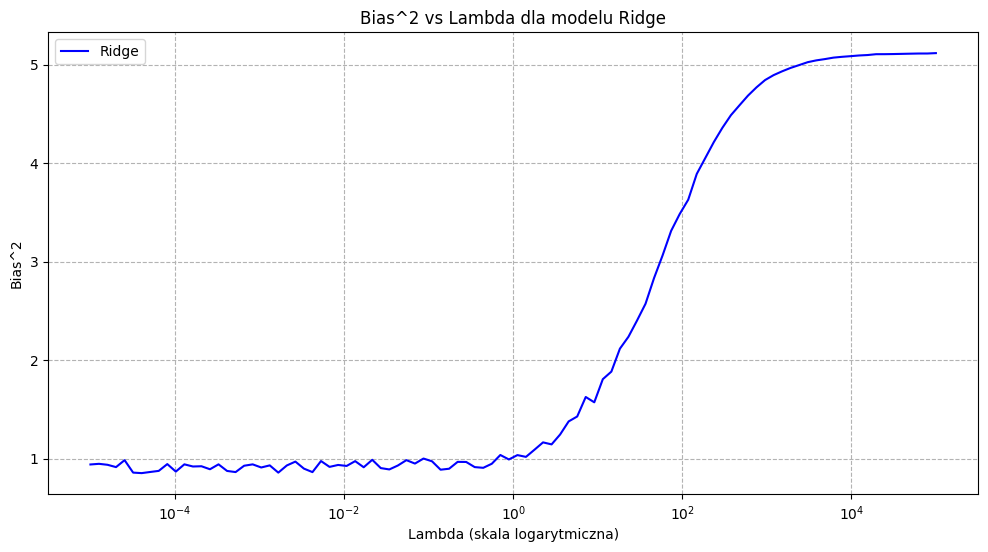

In [70]:
# Wykres Bias^2 dla modelu Ridge
plt.figure(figsize=(12, 6))
ridge_data = data[data['model'] == 'ridge']
plt.plot(ridge_data['lambda'], ridge_data['bias2'], color='blue', label='Ridge')
plt.xscale('log')
plt.title('Bias^2 vs Lambda dla modelu Ridge')
plt.xlabel('Lambda (skala logarytmiczna)')
plt.ylabel('Bias^2')
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.show()

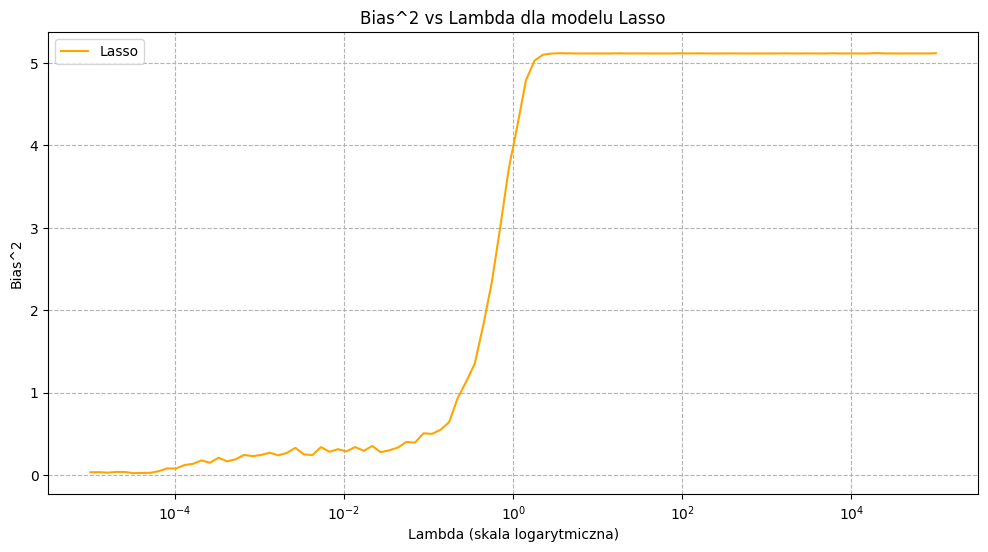

In [71]:
# Wykres Bias^2 dla modelu Lasso
plt.figure(figsize=(12, 6))
lasso_data = data[data['model'] == 'lasso']
plt.plot(lasso_data['lambda'], lasso_data['bias2'], color='orange', label='Lasso')
plt.xscale('log')
plt.title('Bias^2 vs Lambda dla modelu Lasso')
plt.xlabel('Lambda (skala logarytmiczna)')
plt.ylabel('Bias^2')
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.show()

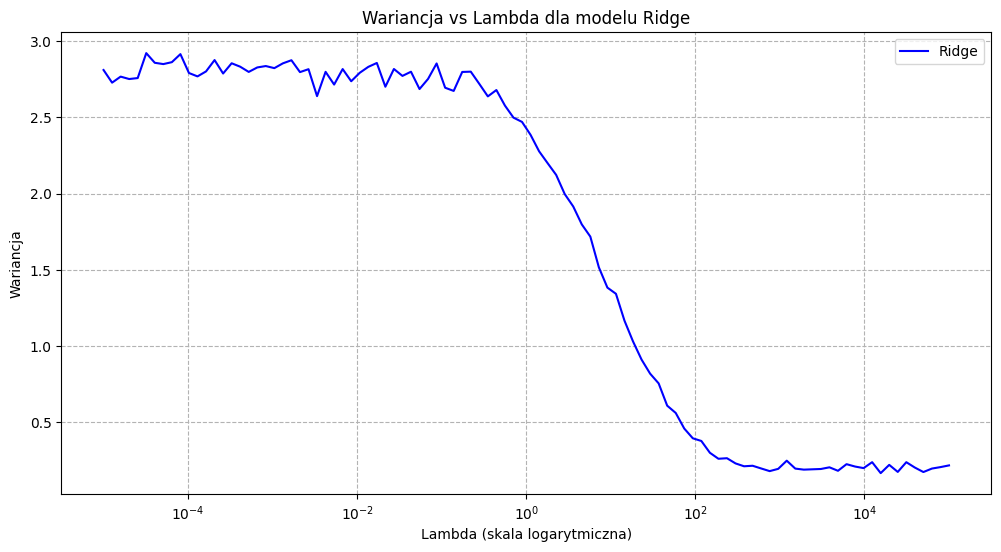

In [72]:
# Wykres wariancji dla modelu Ridge
plt.figure(figsize=(12, 6))
ridge_data = data[data['model'] == 'ridge']
plt.plot(ridge_data['lambda'], ridge_data['variance'], color='blue', label='Ridge')
plt.xscale('log')
plt.title('Wariancja vs Lambda dla modelu Ridge')
plt.xlabel('Lambda (skala logarytmiczna)')
plt.ylabel('Wariancja')
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.show()

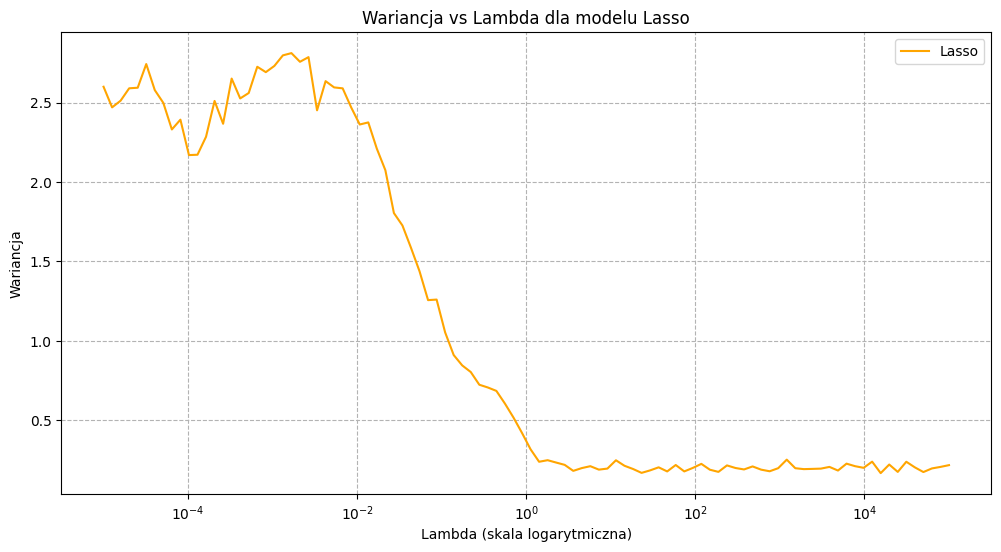

In [73]:
# Wykres wariancji dla modelu Lasso
plt.figure(figsize=(12, 6))
lasso_data = data[data['model'] == 'lasso']
plt.plot(lasso_data['lambda'], lasso_data['variance'], color='orange', label='Lasso')
plt.xscale('log')
plt.title('Wariancja vs Lambda dla modelu Lasso')
plt.xlabel('Lambda (skala logarytmiczna)')
plt.ylabel('Wariancja')
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.show()

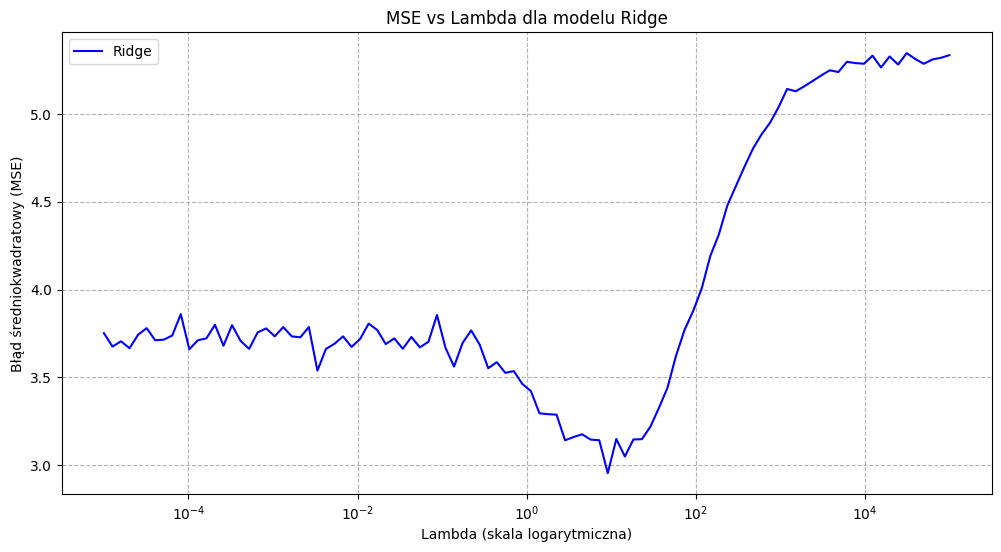

In [74]:
# Wykres MSE dla modelu Ridge
plt.figure(figsize=(12, 6))
ridge_data = data[data['model'] == 'ridge']
plt.plot(ridge_data['lambda'], ridge_data['mse'], color='blue', label='Ridge')
plt.xscale('log')
plt.title('MSE vs Lambda dla modelu Ridge')
plt.xlabel('Lambda (skala logarytmiczna)')
plt.ylabel('Błąd średniokwadratowy (MSE)')
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.show()

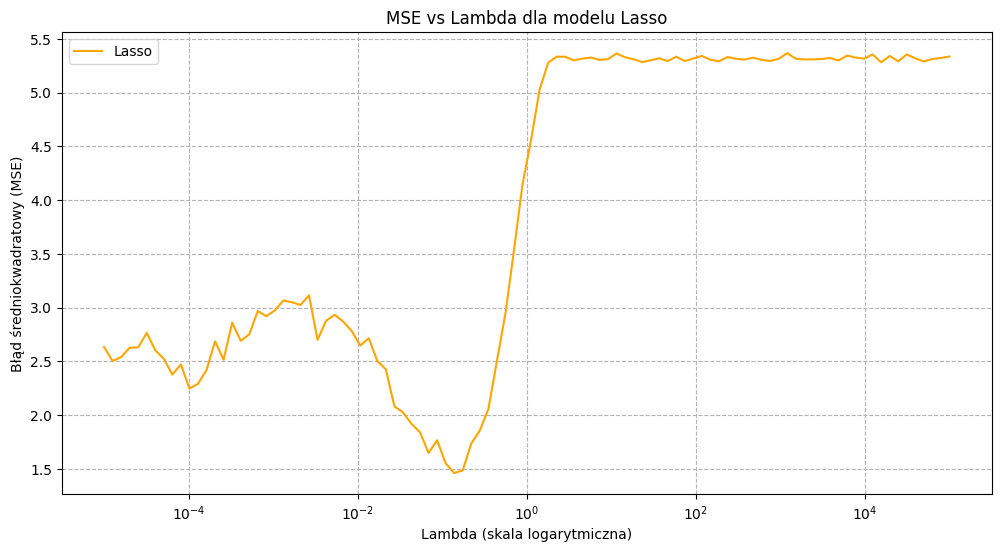

In [75]:
# Wykres MSE dla modelu Lasso
plt.figure(figsize=(12, 6))
lasso_data = data[data['model'] == 'lasso']
plt.plot(lasso_data['lambda'], lasso_data['mse'], color='orange', label='Lasso')
plt.xscale('log')
plt.title('MSE vs Lambda dla modelu Lasso')
plt.xlabel('Lambda (skala logarytmiczna)')
plt.ylabel('Błąd średniokwadratowy (MSE)')
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.show()

# Wyniki
Jak widać Wariancja, Bias i MSE silnie zależą od wybranego parametru lambda przy penalizacji modeli.
Tak jak się spodziewaliśmy dla obydwu metod bias rośnie wraz z siłą penalizacji, wariancja spada, natomiast krzywa MSE pozawala na lepsze dobranie punktu balansującego oba czynniki.
Bez spojrzenia na krzywą MSE może być ciężko znaleźć balans, dla małego lambda model jest zbyt duży i overfitted ucząc się szumu losowego (duża wariancja). Dla zbyt dużego, tracimy istotną część informacji o danych a szum losowy ma wpływ na wybrane do modelu zmienne predykcyjne (duży wzrost biasu).

Ridge regression działa "delikatniej", zmniejszając wagi do wartości bliższych zera, co da lepszy efekt w przypadku modelu w którym nie chcemy odrzucić wielu preduktorów lub są one silnie skorelowane.

Lasso dużo szybciej odrzuci większą liczbę predyktorów zmniejszając ich wagi do zera, lepiej nadając się do zadań typu feature selection.